In [5]:
import pandas as pd
import json
import os
import matplotlib as mpl
from matplotlib import pyplot as plt
import requests
from io import StringIO as sio
from matplotlib.patches import Patch
import matplotlib.ticker as ticker
import re
import itertools
import sys
import baltic as bt

In [6]:
tree_95_path = "prepped/summary-95.nwk"
tree_75_path = "prepped/summary-75.nwk"
original_path = "prepped/backbone.nwk"

paths = [tree_95_path, tree_75_path, original_path]

In [7]:
for tree in paths:
    
    print(tree)

    with open(tree, 'r') as file:
        modified = file.read()

    # removing commas between segments
    def repl(match):
        cleaned = re.sub(r",\s*", "-", match.group(1))
        return f"rea={cleaned}"

    modified = re.sub(r'rea=([^]\)]+)', repl, modified)

    # removing quotation marks around node names
    modified = re.sub(r"'(NODE_\d+)'", r'\1', modified)

    with open(f"{tree}", "w") as output_file:
        output_file.write(modified.strip())

prepped/summary-95.nwk
prepped/summary-75.nwk
prepped/backbone.nwk


In [8]:
tree_95 = bt.loadNewick("prepped/summary-95.nwk", absoluteTime= False)
tree_75 = bt.loadNewick("prepped/summary-75.nwk", absoluteTime= False)
original = bt.loadNewick("prepped/backbone.nwk", absoluteTime= False)

In [9]:
tree_dict = {"tree_95": tree_95, "tree_75": tree_75, "original": original}

In [10]:
reassortment_count = {}
gene_segment_counts = {name: {} for name in tree_dict.keys()}
gene_segments = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']
leaf_list = {name: [] for name in tree_dict.keys()}
nodes = {}
leaves = {}

for name, tree in tree_dict.items():
    
    leaf = []
    node_count = 0
    leaf_count = 0
    count = 0
    tree_segment_counts = {segment: 0 for segment in gene_segments}
    
    for k in tree.Objects:
        if k.traits.get('is_reassorted'):
            
            raw_segments = k.traits["rea"]
            is_uncertain = all([g_str.startswith('_') for g_str in raw_segments.split('-')])
            
            lst = [seg.split("(")[0] for seg in raw_segments.split("-")]
            count += 0.5 if is_uncertain else 1
            
            for seg in lst:
                cleaned_seg = seg.lstrip('_')
                tree_segment_counts[cleaned_seg] += 0.5 if seg.startswith('_') else 1
                
            if k.is_node():
                node_count += 0.5 if is_uncertain else 1
            else:
                leaf_count += 0.5 if is_uncertain else 1
                leaf.append(k.name)
                
    
    leaf_list[name] = leaf
    reassortment_count[name] = count
    nodes[name] = node_count
    leaves[name] = leaf_count
    gene_segment_counts[name] = tree_segment_counts

In [11]:
from itertools import combinations
from collections import defaultdict

reassortment_count = {}
gene_segment_counts = {name: {} for name in tree_dict.keys()}
leaf_list = {name: [] for name in tree_dict.keys()}
nodes = {}
leaves = {}

# New dictionary for co-occurrences
segment_pair_counts = {name: defaultdict(lambda: defaultdict(int)) for name in tree_dict.keys()}

gene_segments = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']

for name, tree in tree_dict.items():
    
    leaf = []
    node_count = 0
    leaf_count = 0
    count = 0
    tree_segment_counts = {segment: 0 for segment in gene_segments}
    
    for k in tree.Objects:
        if k.traits.get('is_reassorted'):
            
            raw_segments = k.traits["rea"]
            is_uncertain = all([g_str.startswith('_') for g_str in raw_segments.split('-')])
            
            lst = [seg.split("(")[0].lstrip('_') for seg in raw_segments.split("-")]
            count += 0.5 if is_uncertain else 1
            
            # Count individual segments
            for seg in lst:
                tree_segment_counts[seg] += 0.5 if seg.startswith('_') else 1
                
            # Count nodes vs leaves
            if k.is_node():
                node_count += 0.5 if is_uncertain else 1
            else:
                leaf_count += 0.5 if is_uncertain else 1
                leaf.append(k.name)
            
            # Count segment pairs (combinations of 2)
            if len(lst) > 1:
                for seg1, seg2 in combinations(lst, 2):
                    # Increment both directions for easy access
                    segment_pair_counts[name][seg1][seg2] += 1
                    segment_pair_counts[name][seg2][seg1] += 1
    
    leaf_list[name] = leaf
    reassortment_count[name] = count
    nodes[name] = node_count
    leaves[name] = leaf_count
    gene_segment_counts[name] = tree_segment_counts


In [12]:
segment_pair_counts

{'tree_95': defaultdict(<function __main__.<dictcomp>.<lambda>()>,
             {'MP': defaultdict(int,
                          {'NP': 32,
                           'NS': 32,
                           'PA': 35,
                           'PB1': 21,
                           'PB2': 30,
                           'NA': 12}),
              'NP': defaultdict(int,
                          {'MP': 32,
                           'NS': 38,
                           'PA': 33,
                           'PB1': 25,
                           'PB2': 36,
                           'NA': 15}),
              'NS': defaultdict(int,
                          {'MP': 32,
                           'NP': 38,
                           'PA': 33,
                           'PB1': 26,
                           'PB2': 32,
                           'NA': 14}),
              'PA': defaultdict(int,
                          {'MP': 35,
                           'NP': 33,
                           'NS': 

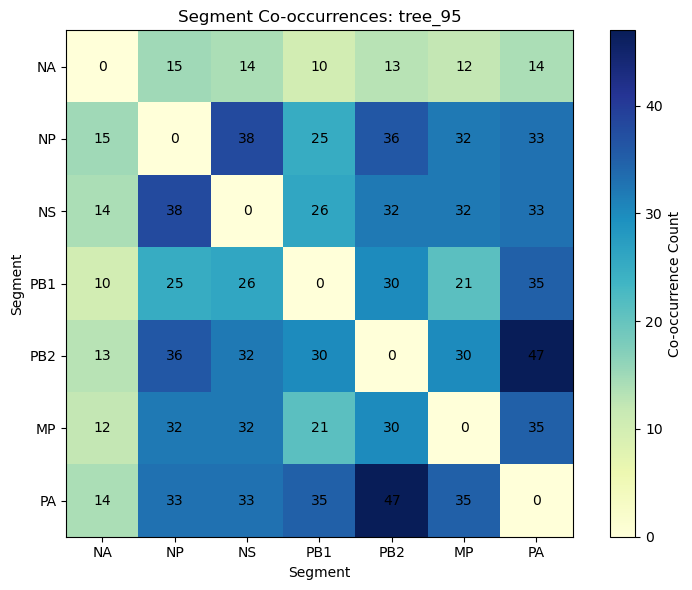

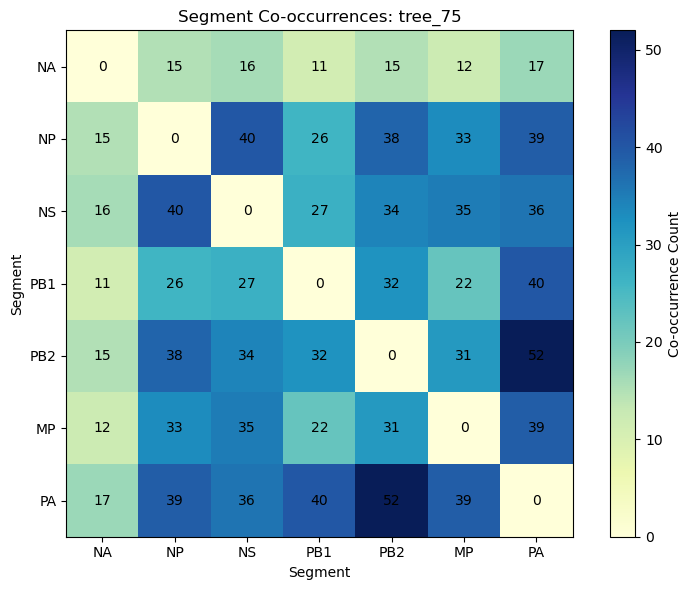

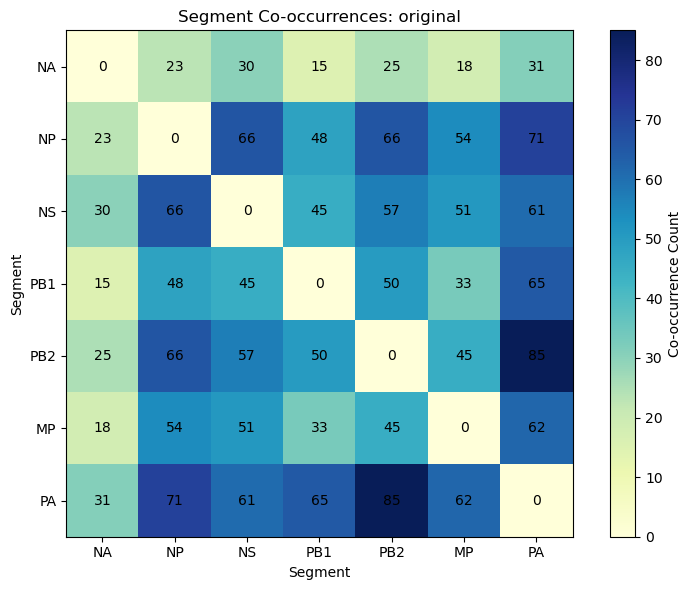

In [13]:
import matplotlib.pyplot as plt
import numpy as np

gene_segments = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']

for name in tree_dict.keys():
    # Create a co-occurrence matrix
    co_matrix = np.zeros((len(gene_segments), len(gene_segments)), dtype=int)
    
    for i, seg1 in enumerate(gene_segments):
        for j, seg2 in enumerate(gene_segments):
            co_matrix[i, j] = segment_pair_counts[name][seg1].get(seg2, 0)
    
    plt.figure(figsize=(8,6))
    im = plt.imshow(co_matrix, cmap='YlGnBu')
    plt.colorbar(im, label='Co-occurrence Count')
    
    # Set axis labels
    plt.xticks(ticks=np.arange(len(gene_segments)), labels=gene_segments)
    plt.yticks(ticks=np.arange(len(gene_segments)), labels=gene_segments)
    
    # Annotate the cells with counts
    for i in range(len(gene_segments)):
        for j in range(len(gene_segments)):
            plt.text(j, i, co_matrix[i, j], ha='center', va='center', color='black')
    
    plt.title(f"Segment Co-occurrences: {name}")
    plt.xlabel("Segment")
    plt.ylabel("Segment")
    plt.tight_layout()
    plt.show()


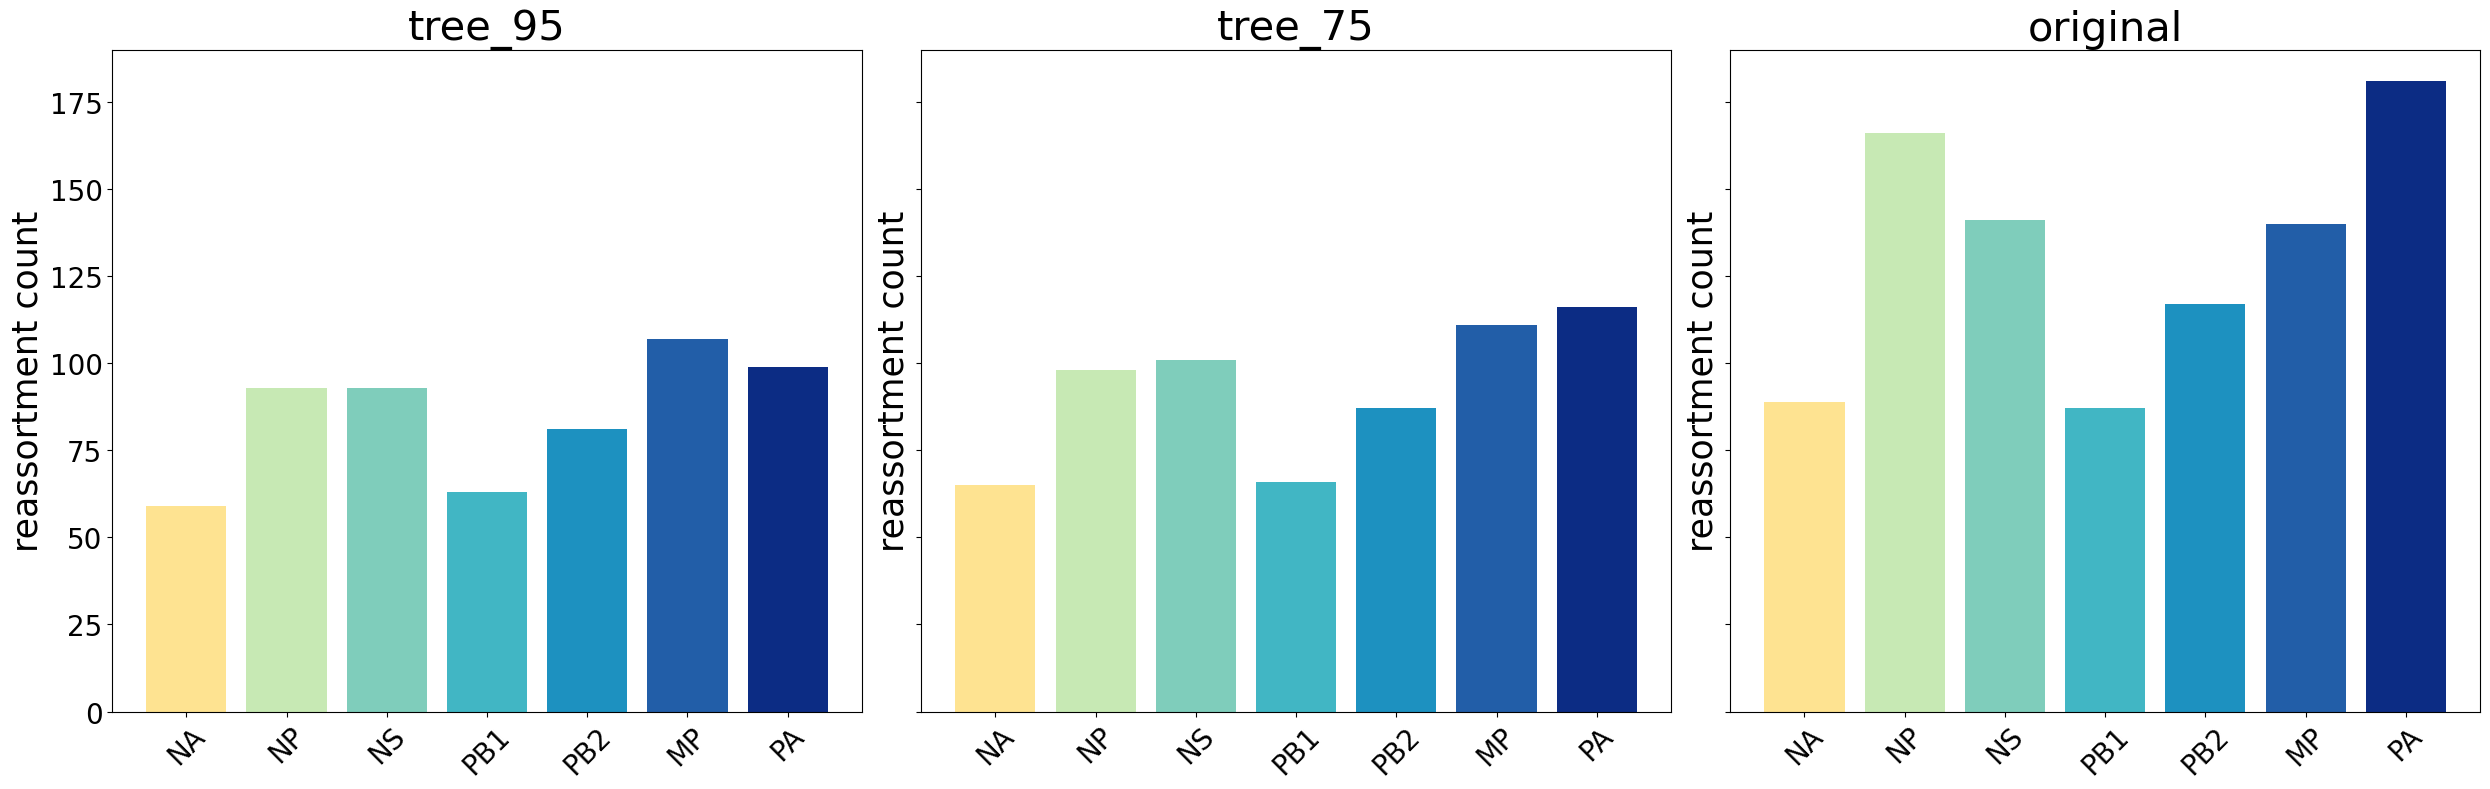

In [14]:
import matplotlib.pyplot as plt
import numpy as np

genes = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']  # consistent order
colors = ['#fee391', '#c7e9b4', '#7fcdbb', '#41b6c4', '#1d91c0', '#225ea8', '#0c2c84']

trees = list(tree_dict.keys())  # ["tree_95", "tree_75", "original"]

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=len(trees), figsize=(25, 8), sharey=True)

if len(trees) == 1:
    axes = [axes]  # make iterable if only one subplot

for idx, tree_name in enumerate(trees):
    ax = axes[idx]
    
    # Values for this tree: one bar per gene
    values = [gene_segment_counts[tree_name][gene] for gene in genes]
    x = np.arange(len(genes))
    
    ax.bar(x, values, color=colors, width=0.8)
    
    ax.set_title(tree_name, fontsize=30)
    ax.set_xticks(x)
    ax.set_xticklabels(genes, rotation=45, fontsize=20)
    ax.set_ylabel('reassortment count', fontsize=25)
    ax.tick_params(axis='y', labelsize=20)

plt.tight_layout()
plt.show()


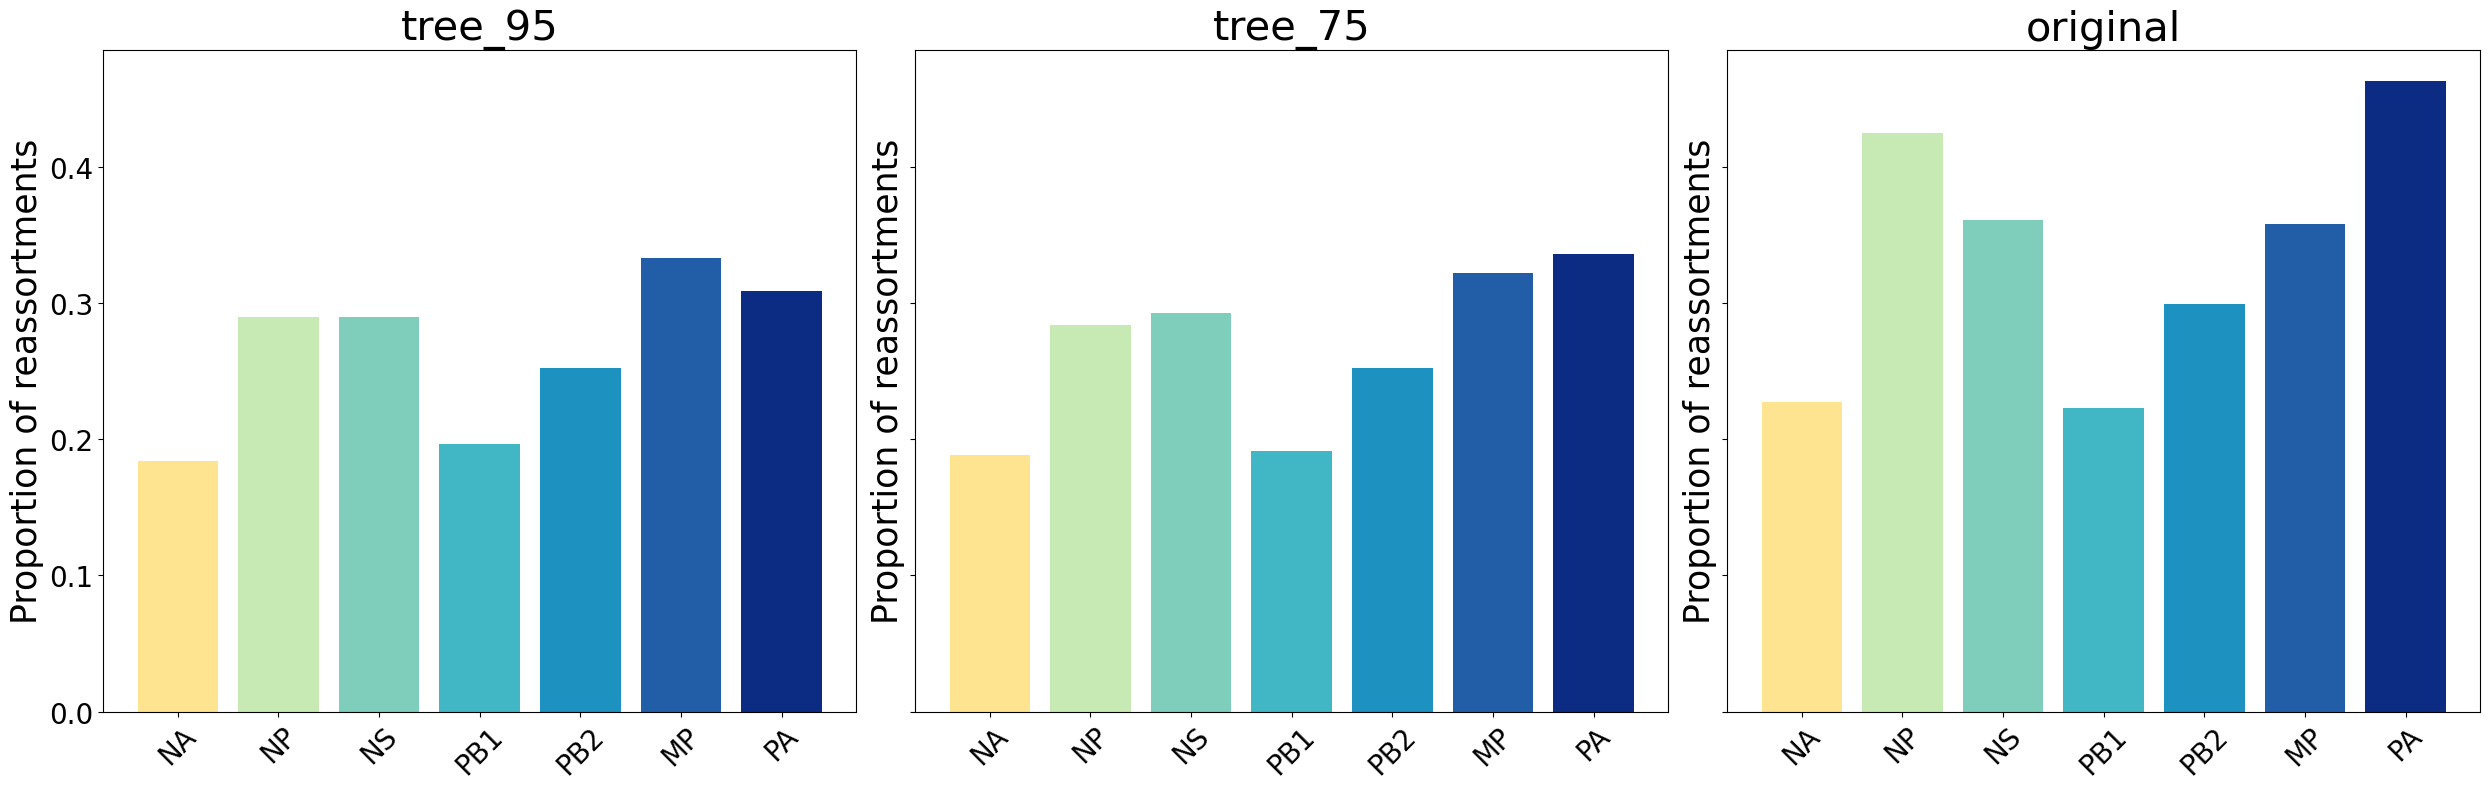

In [15]:
import matplotlib.pyplot as plt
import numpy as np

genes = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']  # consistent order
colors = ['#fee391', '#c7e9b4', '#7fcdbb', '#41b6c4', '#1d91c0', '#225ea8', '#0c2c84']

trees = list(tree_dict.keys())  # ["tree_95", "tree_75", "original"]

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=len(trees), figsize=(25, 8), sharey=True)

if len(trees) == 1:
    axes = [axes]  # make iterable if only one subplot

for idx, tree_name in enumerate(trees):
    ax = axes[idx]
    
    total_reassort = reassortment_count[tree_name]  # total reassortments for this tree
    # Values for this tree: proportion per gene
    values = [gene_segment_counts[tree_name][gene] / total_reassort for gene in genes]
    
    x = np.arange(len(genes))
    
    ax.bar(x, values, color=colors, width=0.8)
    
    ax.set_title(tree_name, fontsize=30)
    ax.set_xticks(x)
    ax.set_xticklabels(genes, rotation=45, fontsize=20)
    ax.set_ylabel('Proportion of reassortments', fontsize=25)
    ax.tick_params(axis='y', labelsize=20)

plt.tight_layout()
plt.show()


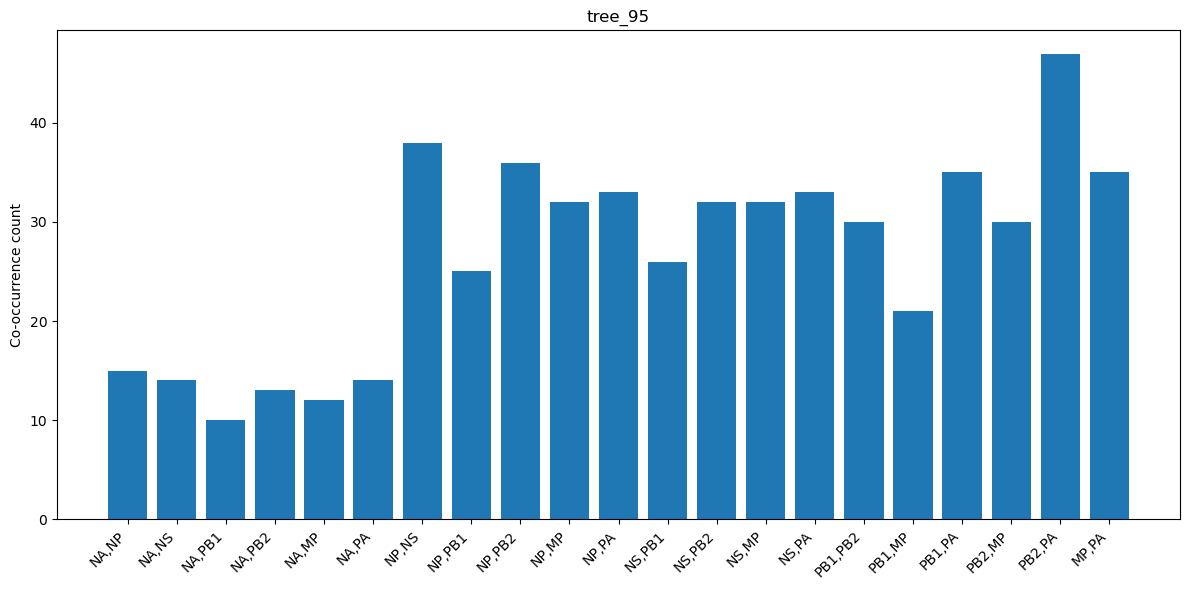

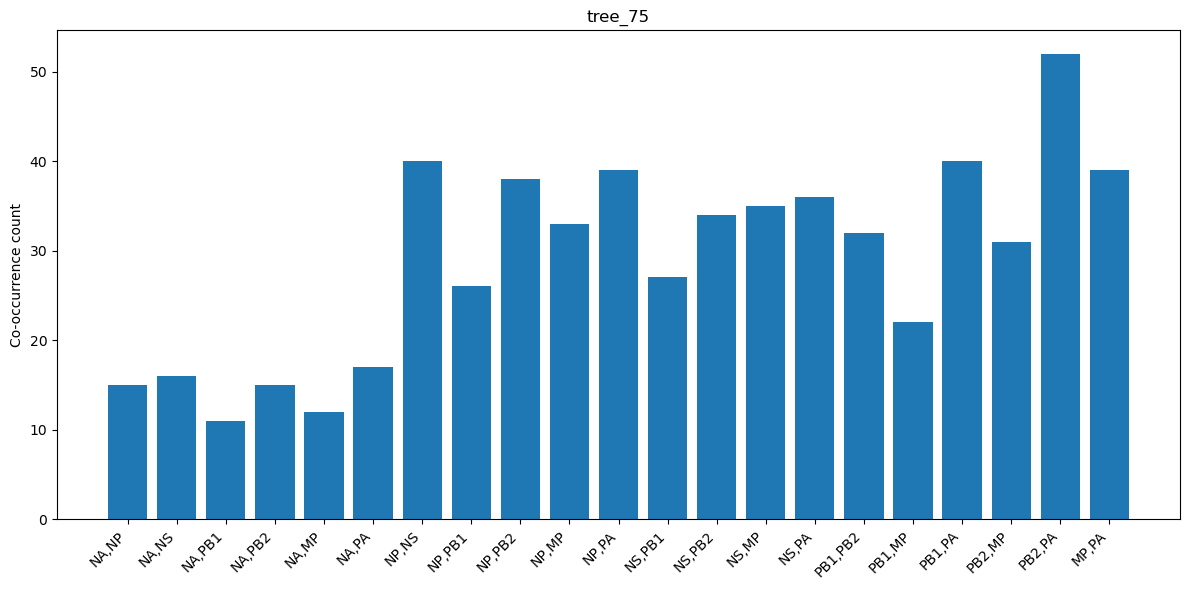

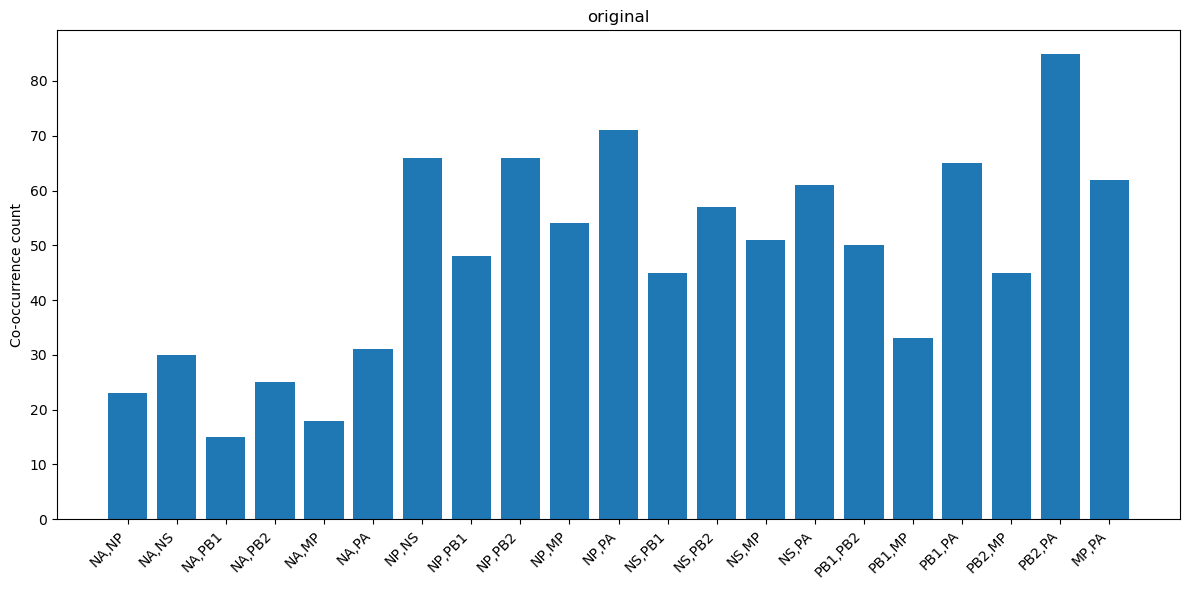

In [16]:
import matplotlib.pyplot as plt
import itertools

gene_segments = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']

for name in tree_dict.keys():
    pairs = []
    counts = []

    # Flatten the segment_pair_counts into pairs and counts
    for i, seg1 in enumerate(gene_segments):
        for j, seg2 in enumerate(gene_segments):
            if i < j:  # only count each pair once
                count = segment_pair_counts[name][seg1].get(seg2, 0)
                if count > 0:
                    pairs.append(f"{seg1},{seg2}")
                    counts.append(count)
    
    # Create bar plot
    plt.figure(figsize=(12,6))
    plt.bar(pairs, counts)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Co-occurrence count")
    plt.title(name)
    plt.tight_layout()
    plt.show()


In [17]:
import itertools

gene_segments = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']

for name in tree_dict.keys():
    missing_pairs = []

    # Loop over all unique pairs
    for seg1, seg2 in itertools.combinations(gene_segments, 2):
        count = segment_pair_counts[name][seg1].get(seg2, 0)
        if count == 0:
            missing_pairs.append(f"{seg1},{seg2}")
    
    print(f"Tree: {name}")
    print("Missing segment pairs:", missing_pairs)
    print()


Tree: tree_95
Missing segment pairs: []

Tree: tree_75
Missing segment pairs: []

Tree: original
Missing segment pairs: []

